# **Problem Statement**

### **Business Context**

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data Scientist at AllLife Bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### **Objectives**

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and to identify which segment of customers to target more.

### **Data Dictionary**


1. **ID**: Customer ID  
2. **Age**: Customer’s age in completed years  
3. **Experience**: Number of years of professional experience  
4. **Income**: Annual income of the customer (in thousand dollars)  
5. **ZIP Code**: Home address ZIP code  
6. **Family**: Family size of the customer  
7. **CCAvg**: Average spending on credit cards per month (in thousand dollars)  
8. **Education**: Education level  
   - 1: Undergrad  
   - 2: Graduate  
   - 3: Advanced/Professional  
9. **Mortgage**: Value of house mortgage, if any (in thousand dollars)  
10. **Personal_Loan**: Indicates if the customer accepted the personal loan offered in the last campaign  
11. **Securities_Account**: Indicates if the customer has a securities account with the bank  
12. **CD_Account**: Indicates if the customer has a certificate of deposit (CD) account with the bank  
13. **Online**: Indicates if the customer uses internet banking facilities  
14. **CreditCard**: Indicates if the customer uses a credit card issued by another bank (excluding All Life Bank)  


# **Importing the necessary libraries**

In [0]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

# **Loading the data**

In [0]:
# Loading the data from databricks storage
import os
file_path = os.path.abspath('../Storage/Loan_Modelling.csv')
Loan_approval = pd.read_csv(file_path, on_bad_lines='skip')

In [0]:
# creating a copy of the data
data = Loan_approval.copy()

# **Data Overview**

### Viewing the first and last 5 rows of the dataset

In [0]:
data.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [0]:
data.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Checking the shape of the dataset.

In [0]:
data.shape

(5000, 14)

- The dataset has 5000 rows and 14 columns.

### Checking the attribute types

In [0]:
data.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- All columns are numerical in nature
- CCAvg is of type float, rest all are integers

### Checking the statistical summary

In [0]:
data.describe(include="all")

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


- Average Age of Customers is ~45 years
- Customers have professional experience on average of 20 years
  - Experience has few negative values which needs to be fixed or evaluated correctly
- Average income stood at around $ 73K annually, with 25% of customers earn close to or above $ 100k
- Average credit card spending of customers are $ 2K
  - 29% customers have credit card
- Few high cardinality columns such as ID and ZipCode are not adding much value to datset
- Only 9.6% customers have accepted loan offer
- 60% of customers are online customers

### Checking for missing values

In [0]:
# checking for null values
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

- There are no missing values in the dataset.

### Checking for duplicate values

In [0]:
# checking for duplicate values
data.duplicated().sum()

0

* There are no duplicate values in the data.

### Dropping the columns with all unique values

In [0]:
data["ID"].nunique()

5000

In [0]:
data['ZIPCode'].nunique()

467

In [0]:
# Dropping ID Column as it is unique
data.drop(["ID"], axis=1, inplace=True)

In [0]:
# Dropping ZIPCode column as it has high cardinality
data.drop(["ZIPCode"], axis=1, inplace=True)

# **Exploratory Data Analysis**

### Univariate Analysis

In [0]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

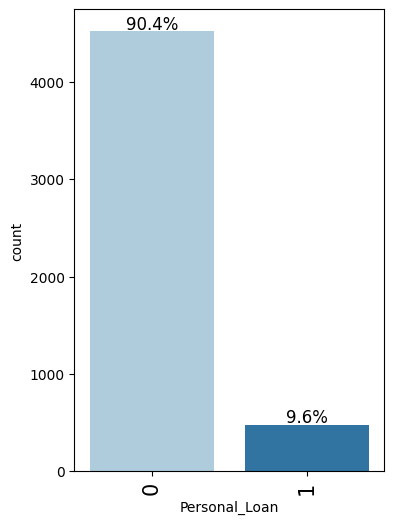

In [0]:
labeled_barplot(data, "Personal_Loan", perc=True)

- Only 9.6% have personal loan

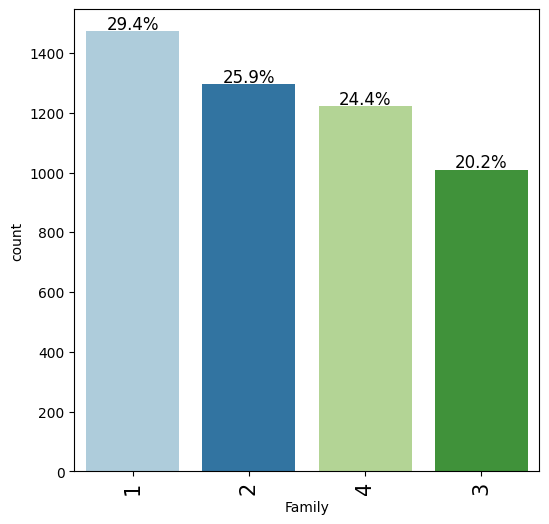

In [0]:
labeled_barplot(data, "Family", perc=True)

* We have 30% customers with 1 dependent, the distribution here don't make very high differences

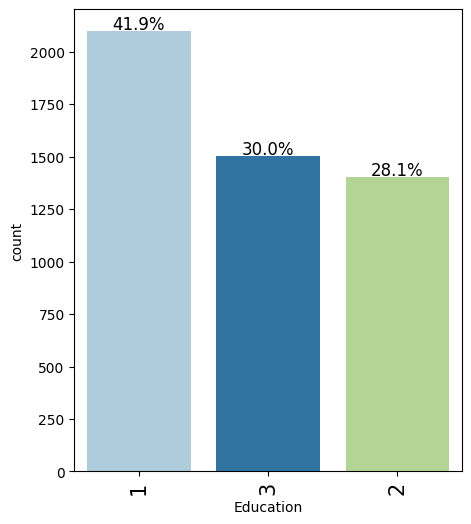

In [0]:
labeled_barplot(data, "Education", perc=True)  # Verify if 'ccavg' exists in data columns

- Undergraduates are more likely to buy personal loan

- Income is right-skewed distribution

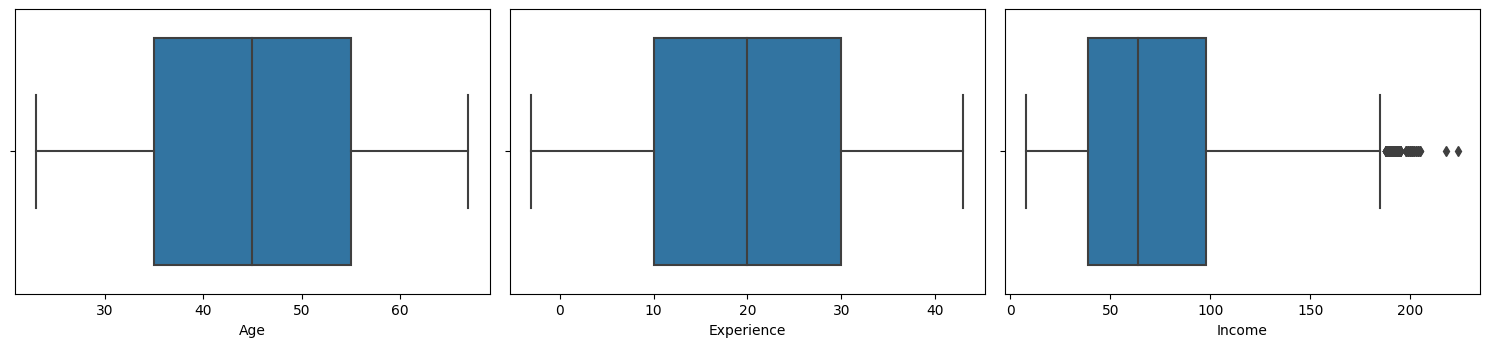

In [0]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Age', 'Experience', 'Income']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

- Average Age is 45 years
- Average experience of customers is 20 years
- Income has outliers, the average income is around $65k

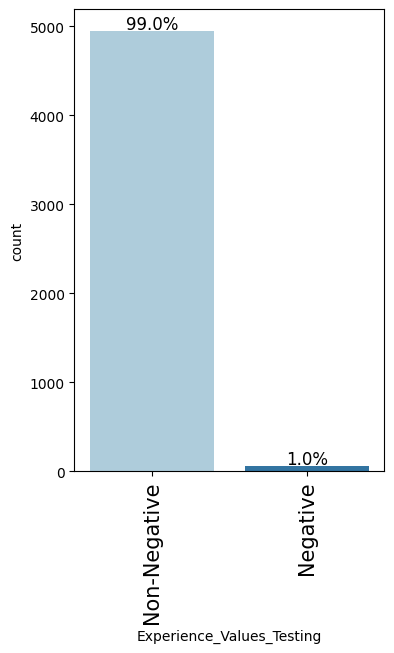

In [0]:
# Identifying the Customers with invalid Experience values
labeled_barplot(
    data.assign(Experience_Values_Testing=np.where(data['Experience'] < 0, 'Negative', 'Non-Negative')),
    'Experience_Values_Testing',
    perc=True
)


- 1% customers have negative values in Experience, which needs to be corrected

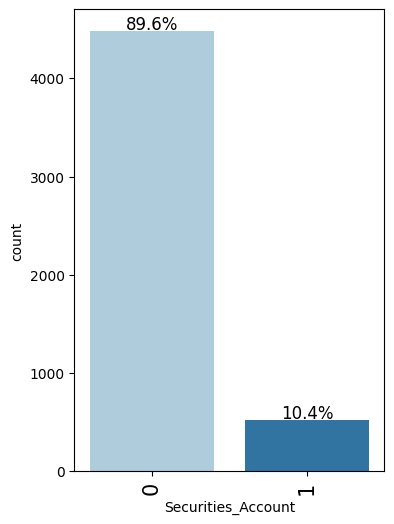

In [0]:
labeled_barplot(data, "Securities_Account", perc=True)

- 90% don't have a security account with bank

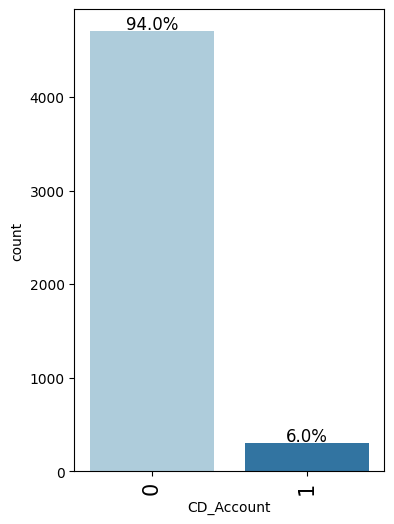

In [0]:
labeled_barplot(data, "CD_Account", perc=True)

- 94% customers don't have CD_Account with bank








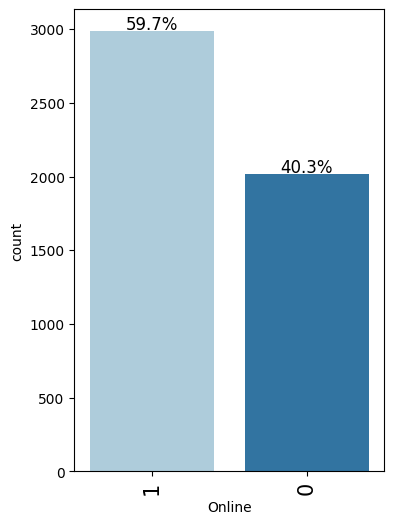

In [0]:
labeled_barplot(data, "Online", perc=True)

- 60% of the customers are Online users

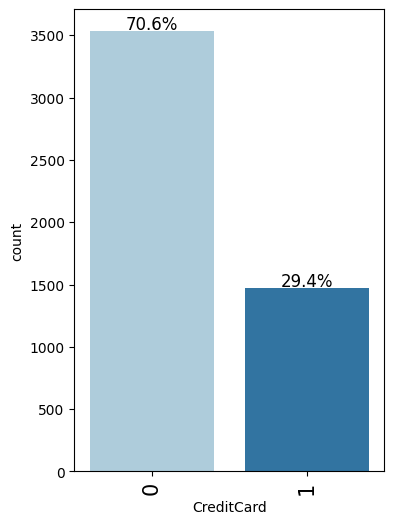

In [0]:
labeled_barplot(data, "CreditCard", perc=True)

- ~70% customers have credit card issued by another bank

### Bivariate Analysis

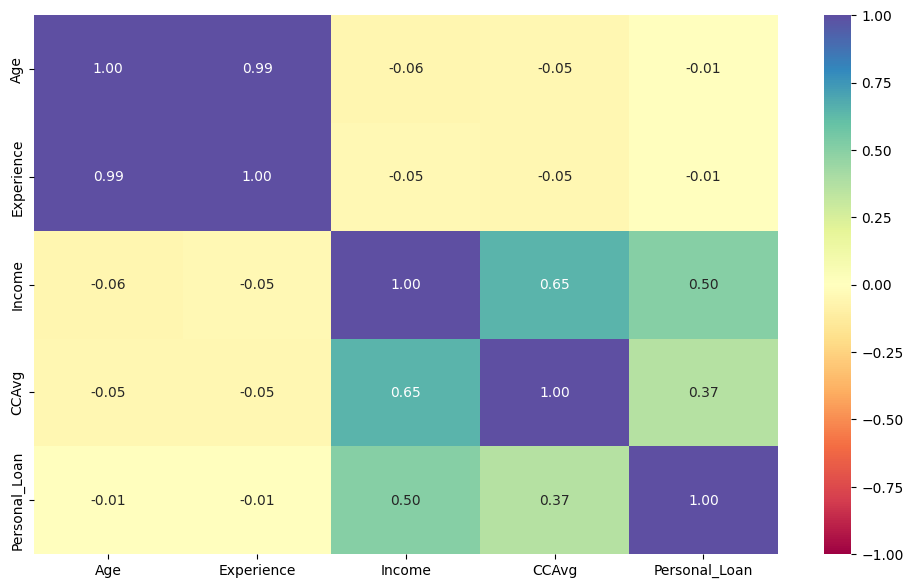

In [0]:
# defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
num_features = ['Age', 'Experience', 'Income', 'CCAvg',  'Personal_Loan']
sns.heatmap(
    data[num_features].corr(),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

- Age and Experience of highly correlated, as age increase the experience of customer increases, which is expected
- Income shows very weak negative correlation with both Age and Experience
- Credit Card Averge spending (CCAvg) is higher with higher income, which is also expected
- Personal Loan has good positive correlation with Income and CCAvg making it the best features to consider for Decision Tree Classifier

<Figure size 1200x800 with 0 Axes>

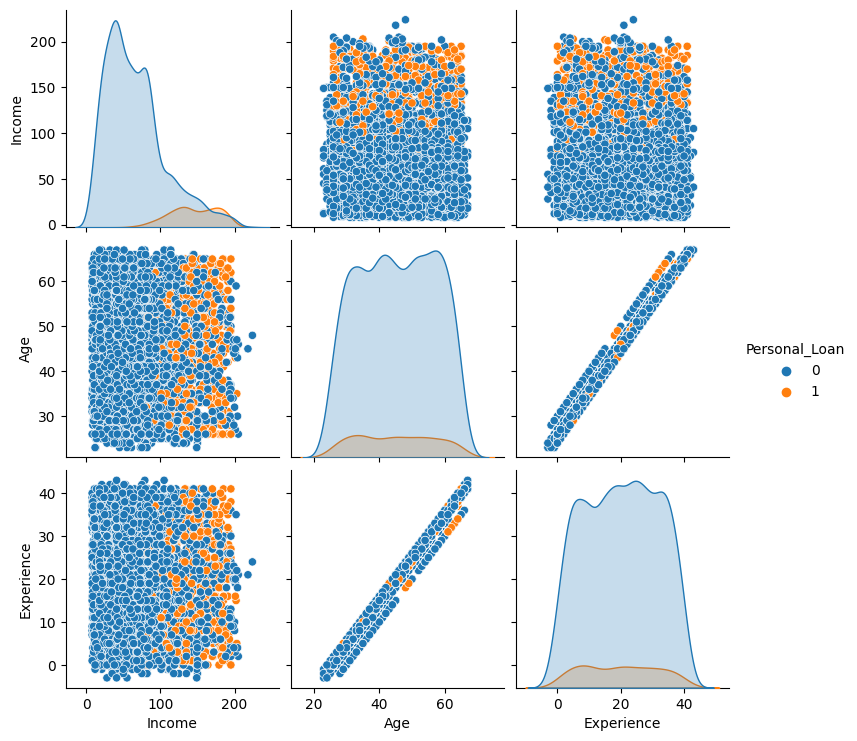

In [0]:
# Scatter plot matrix

num_features = ['Income', 'Age', 'Experience']

plt.figure(figsize=(12, 8))
sns.pairplot(data, vars=num_features, hue='Personal_Loan', diag_kind='kde');

- Higher Income Strongly Correlates with Loan Acceptance
- Age and Experience are Linearly Related but Not Strong Predictors Alone

In [0]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts, percentage metrics, and plot a stacked bar chart.

    data: dataframe
    predictor: independent variable (categorical or binary)
    target: target variable (binary: 0/1)
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]

    # Normalized stacked percentages (for plot)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    
    print("\nLoan Acceptance Percentages by '{}':\n".format(predictor))
    if 1 in tab.columns:
        acceptance_rates = (tab[1] * 100).round(2)
    else:
        # Handle case where no positive class (1) in column
        acceptance_rates = pd.Series([0]*len(tab), index=tab.index)

    for category, rate in acceptance_rates.items():
        print(f"{predictor} = {category} --> Loan Acceptance = {rate:.2f}%")

    print("\n" + "-" * 80)

    # Stacked bar plot
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 6))
    plt.title(f"Loan Acceptance by {predictor}")
    plt.xlabel(predictor)
    plt.ylabel(target)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title=target)
    plt.tight_layout()
    plt.show()



Loan Acceptance Percentages by 'Family':

Family = 3 --> Loan Acceptance = 13.17%
Family = 4 --> Loan Acceptance = 10.97%
Family = 2 --> Loan Acceptance = 8.18%
Family = 1 --> Loan Acceptance = 7.27%

--------------------------------------------------------------------------------


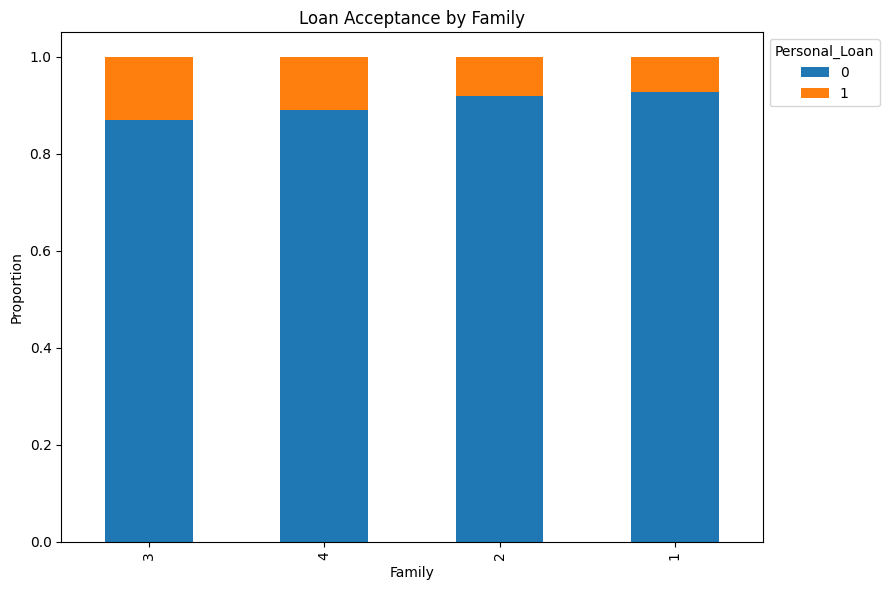

In [0]:
stacked_barplot(data, "Family", "Personal_Loan")

- Little variation observed with increasing family size, more chances of buying a loan


Loan Acceptance Percentages by 'Education':

Education = 3 --> Loan Acceptance = 13.66%
Education = 2 --> Loan Acceptance = 12.97%
Education = 1 --> Loan Acceptance = 4.44%

--------------------------------------------------------------------------------


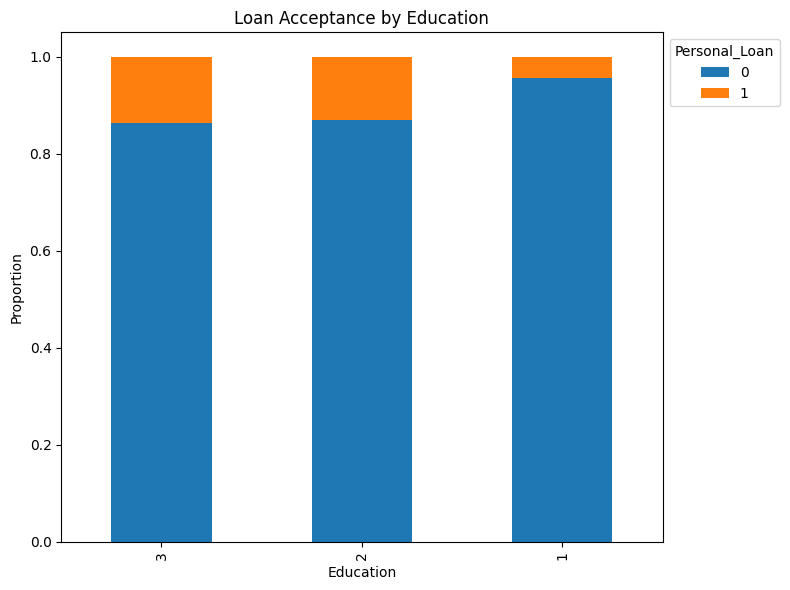

In [0]:
stacked_barplot(data, "Education", "Personal_Loan")

- Higher the education, more chances of buying a loan


Loan Acceptance Percentages by 'CreditCard':

CreditCard = 1 --> Loan Acceptance = 9.73%
CreditCard = 0 --> Loan Acceptance = 9.55%

--------------------------------------------------------------------------------


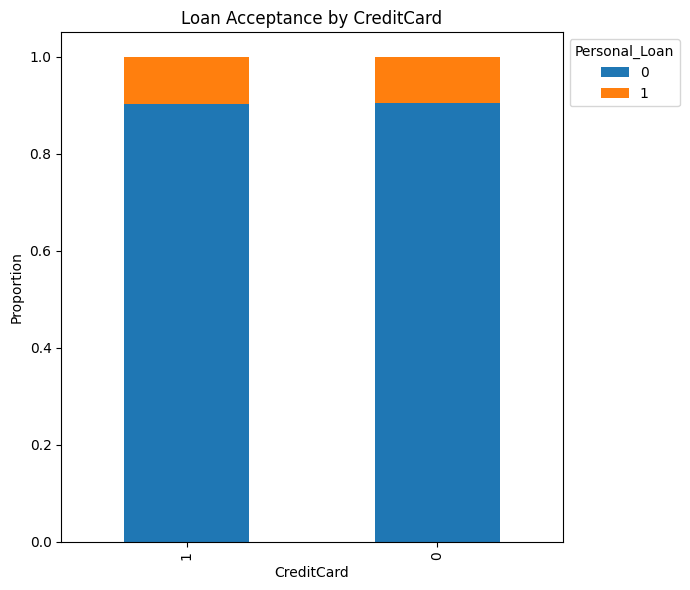

In [0]:
stacked_barplot(data, "CreditCard", "Personal_Loan")

- Customers without CreditCard:
  - Acceptance rate = 337 / 3530 = 9.5%
- Customers with CreditCard:
  - Acceptance rate = 143 / 1470 = 9.7%

Very little variation, creditcard alone is not a strong indicator of converting a customer for loan application 


Loan Acceptance Percentages by 'CD_Account':

CD_Account = 1 --> Loan Acceptance = 46.36%
CD_Account = 0 --> Loan Acceptance = 7.24%

--------------------------------------------------------------------------------


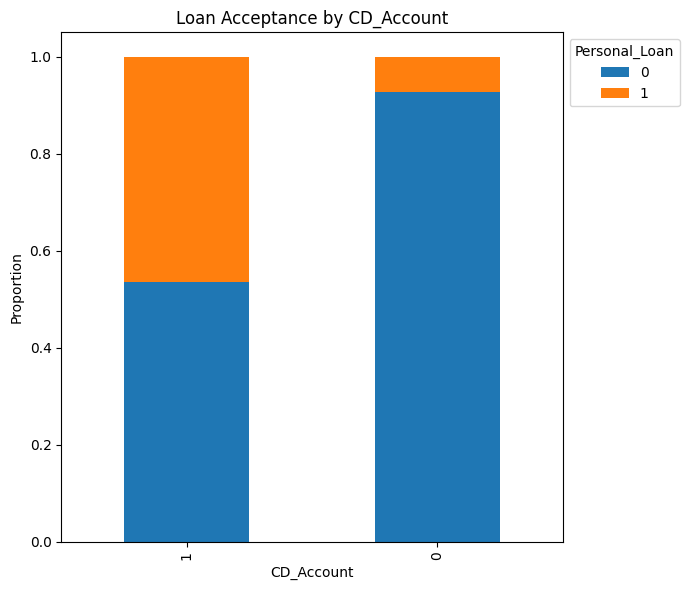

In [0]:
stacked_barplot(data, "CD_Account", "Personal_Loan")


- Customers with a CD_Account ( 46.4%) are more likely to accept a personal loan
- Customers with no CD_Account (7.2%) are less likely to accept a personal loan


Loan Acceptance Percentages by 'Securities_Account':

Securities_Account = 1 --> Loan Acceptance = 11.49%
Securities_Account = 0 --> Loan Acceptance = 9.38%

--------------------------------------------------------------------------------


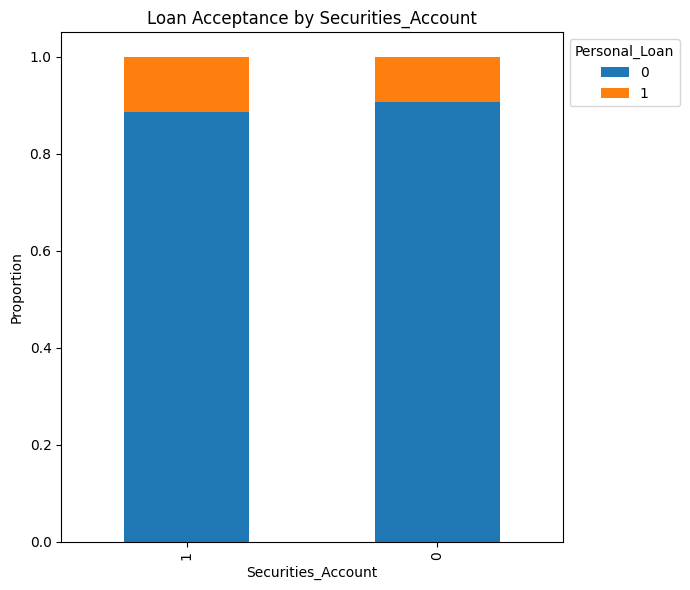

In [0]:
stacked_barplot(data, "Securities_Account", "Personal_Loan")

- Securities_Account = 0, Loan acceptance = 9.4%
- Securities_Account = 1, Loan acceptance =  11.5%


Loan Acceptance Percentages by 'Online':

Online = 1 --> Loan Acceptance = 9.75%
Online = 0 --> Loan Acceptance = 9.38%

--------------------------------------------------------------------------------


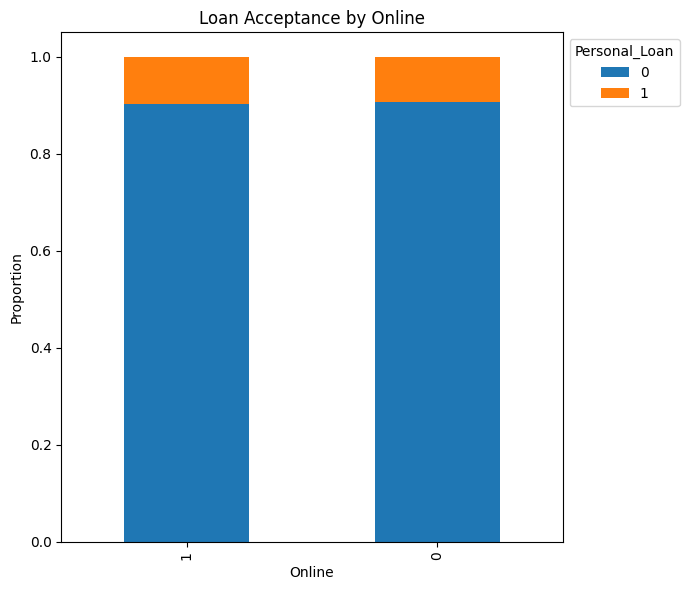

In [0]:
stacked_barplot(data, "Online", "Personal_Loan")

- Online Customers have more chances of getting converted, 9.7% are online with loan
- Offline customers have 9.3% chances of loan acceptance

<Axes: xlabel='Personal_Loan', ylabel='Income'>

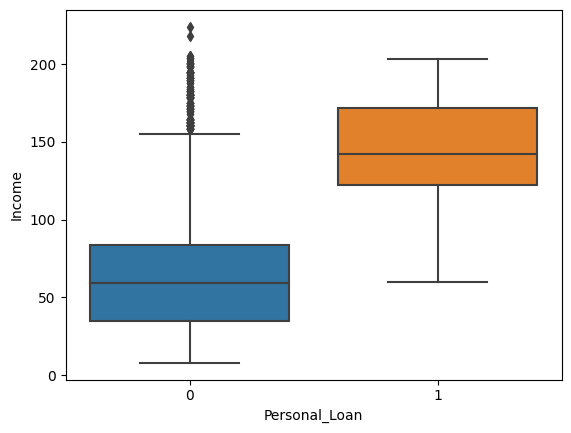

In [0]:
sns.boxplot(x='Personal_Loan', y='Income', data=data)

- Personal loan is approved for high income range, Income ~ $ 140K

# **Data PreProcessing**

In [0]:
# Imputation in Experience column where Experience is negative

#Calculate median from valid experience values
valid_exp = data[data['Experience'] >= 0]['Experience'].median()

# Replace invalid experience values
data.loc[data['Experience'] < 0, 'Experience'] = valid_exp

In [0]:
neg_count = (data['Experience'] < 0).sum()
print(f"Negative Experience values remaining: {neg_count}")

Negative Experience values remaining: 0


# **Data Preparation for Modeling**

In [0]:
# defining the explanatory (independent) and response (dependent) variables
X = data.drop(["Personal_Loan"], axis=1)
y = data["Personal_Loan"]

In [0]:
# creating dummy variables
X = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)

# specifying the datatype of the independent variables data frame
X = X.astype(float)

X.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Securities_Account,CD_Account,Online,CreditCard
0,25.0,1.0,49.0,4.0,1.6,1.0,0.0,1.0,0.0,0.0,0.0
1,45.0,19.0,34.0,3.0,1.5,1.0,0.0,1.0,0.0,0.0,0.0
2,39.0,15.0,11.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,35.0,9.0,100.0,1.0,2.7,2.0,0.0,0.0,0.0,0.0,0.0
4,35.0,8.0,45.0,4.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0


- Since we dont have any categorical variable, there are no encoding done in the data

In [0]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Personal_Loan, dtype: int64

In [0]:
# splitting the data in an 80:20 ratio for train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)    # stratify ensures that the training and test sets have a similar distribution of the response variable

In [0]:
# stratification helped in having fair distribution of response variable aross training and testing data
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')
print("Percentage of classes in training set:")
print(100*y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*y_test.value_counts(normalize=True))

Shape of training set: (4000, 11)
Shape of test set: (1000, 11) 

Percentage of classes in training set:
0    90.4
1     9.6
Name: Personal_Loan, dtype: float64 

Percentage of classes in test set:
0    90.4
1     9.6
Name: Personal_Loan, dtype: float64


# **Model Building**

### Decision Tree Classifier


In [0]:
# creating an instance of the decision tree model
dtree1 = DecisionTreeClassifier(random_state=42)    # random_state sets a seed value and enables reproducibility

# fitting the model to the training data
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#### Model Evaluation

In [0]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  
    # to compute Accuracy, If decision predicts 0 or 1, how often did it get right from actual 0 and 1
    recall = recall_score(target, pred)  
    # to compute Recall, If I am looking at actual 1's , how many of them could I predict as 1
    precision = precision_score(target, pred)  
    # to compute Precision, If I am looking at predicted 1's, how many of them are actually 1
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [0]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    # Set the figure size for the plot
    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

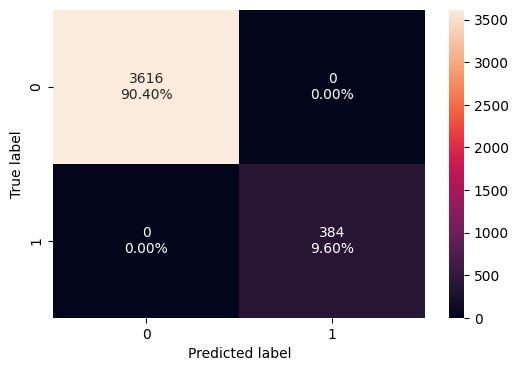

In [0]:
plot_confusion_matrix(dtree1, X_train, y_train)

- No false positives and false negativies

In [0]:
dtree1_train_perf = model_performance_classification(
    dtree1, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


- Perfect accuracy on training data

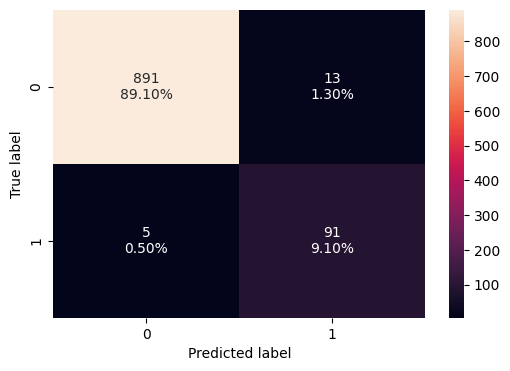

In [0]:
plot_confusion_matrix(dtree1, X_test, y_test)

- The default model achieves perfect accuracy on training data but performs less optimally on test data, indicating overfitting

In [0]:
dtree1_test_perf = model_performance_classification(
    dtree1, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.982,0.947917,0.875,0.91


- Model is giving good and generalized results on training and test set.

#### Visualizing the Decision Tree

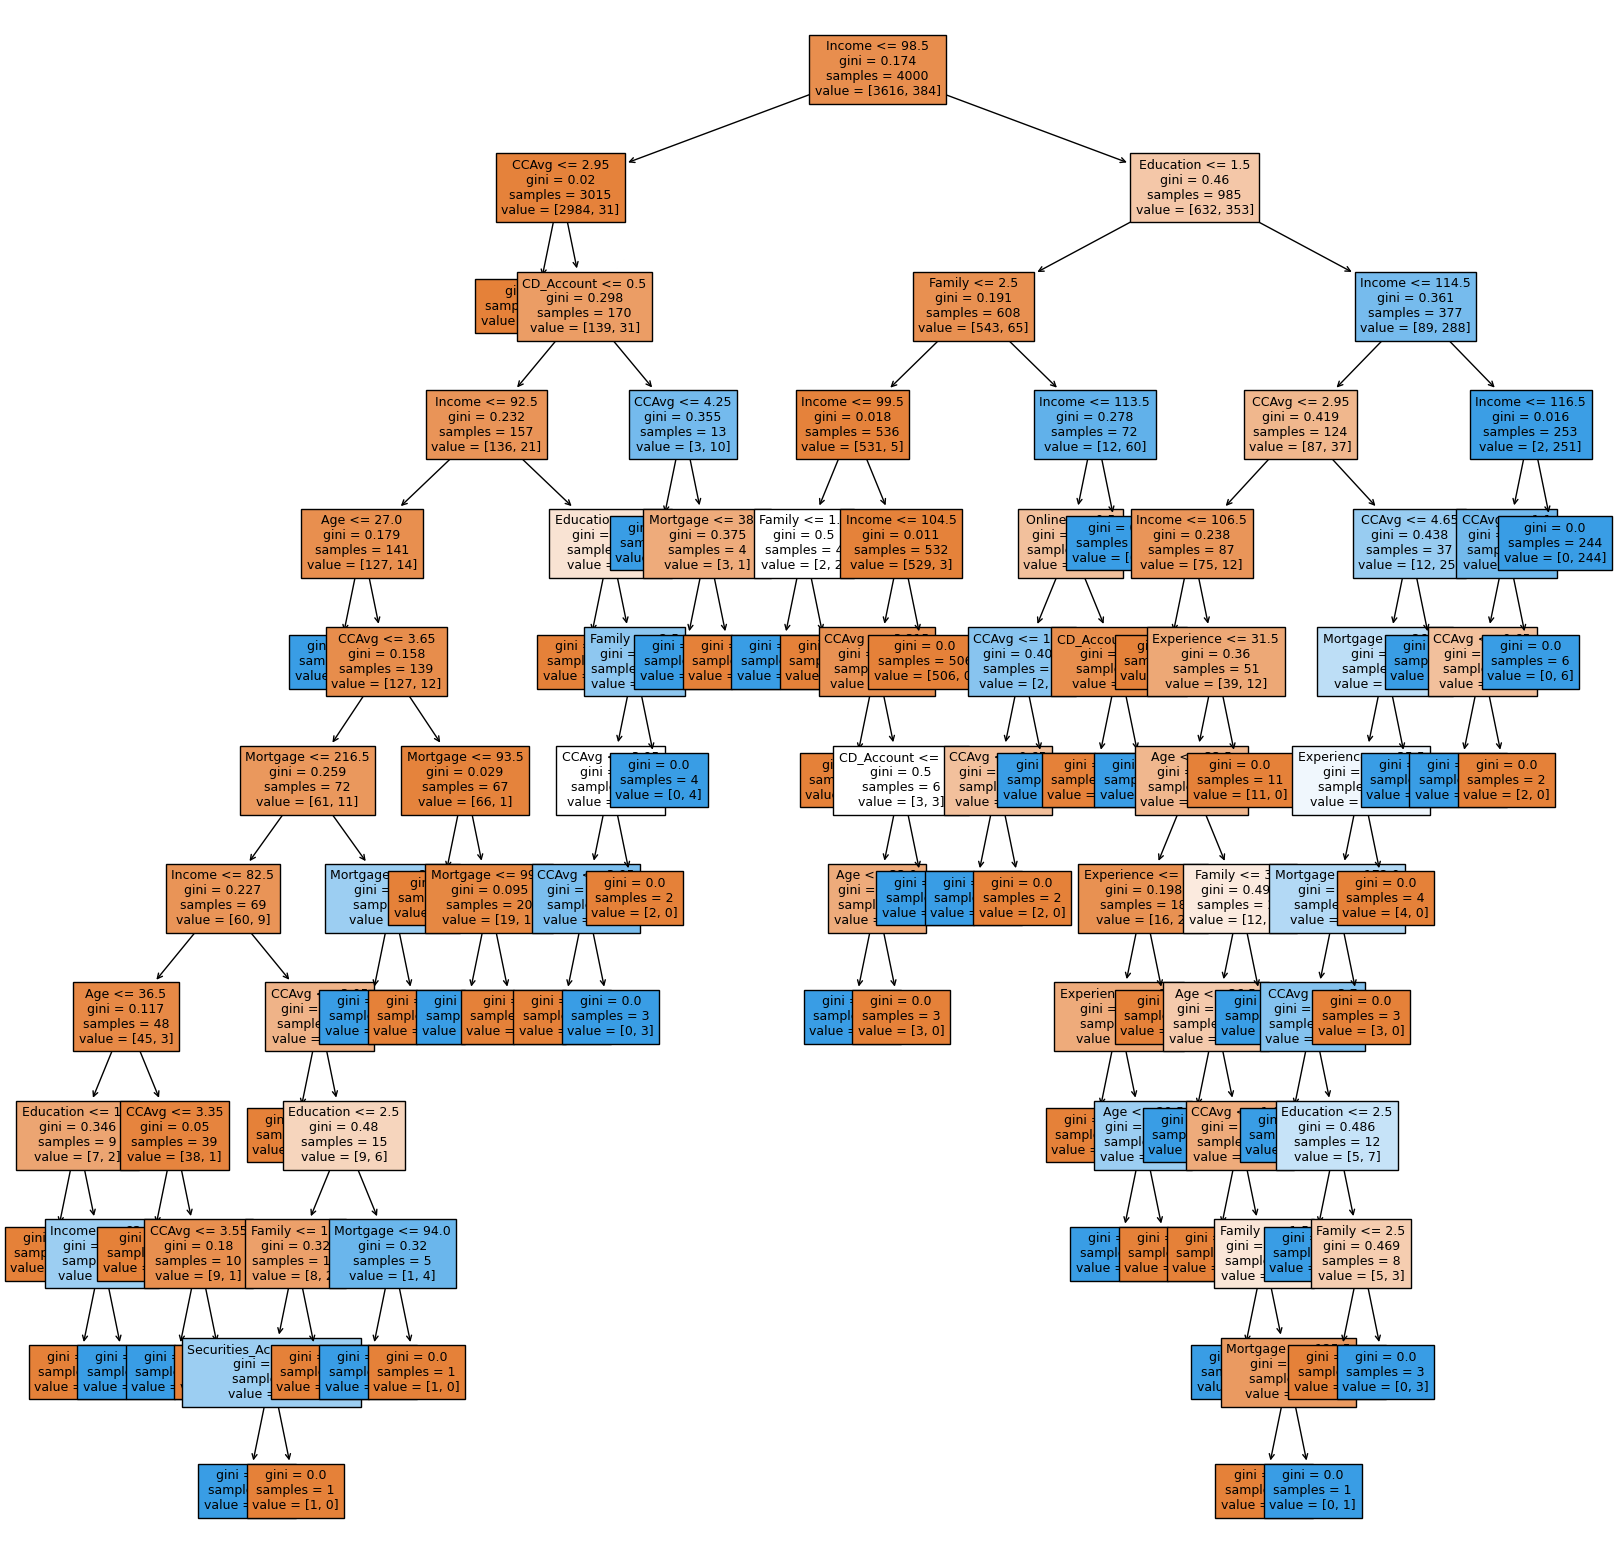

In [0]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- We can observe that this is a very complex tree.
- Every observation in training set is leaf node 

In [0]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree1,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- Age <= 36.50
|   |   |   |   |   |   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- Education >  1.50
|   |   |   |   |   |   |   |   |   |   |--- Income <= 63.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |--- Income >  63.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |   |   |   |   |--

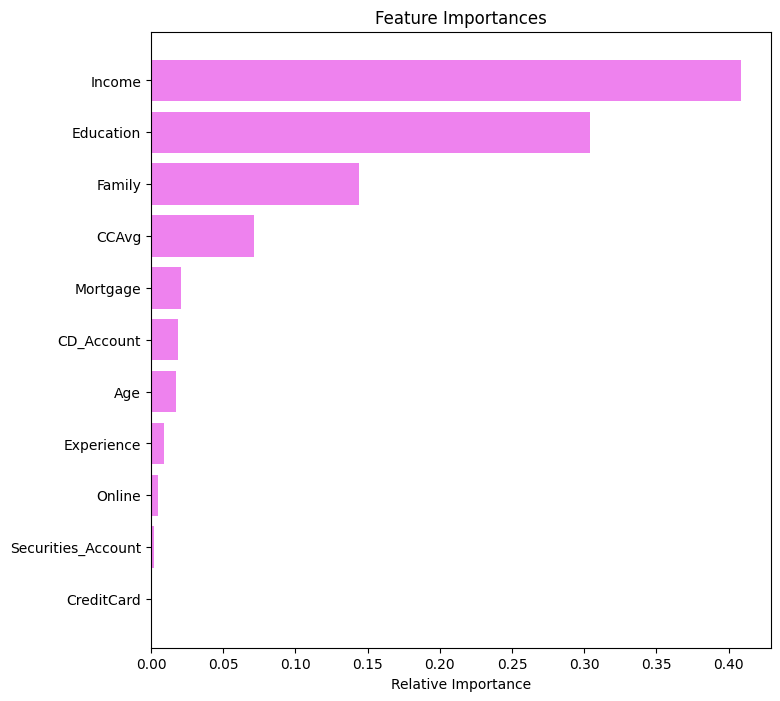

In [0]:
# features used by default tree
importances = dtree1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Decision tree in default settings uses 10 features. It avoids CreditCard holders feature

### Decision Tree (Pre-pruning)

In [0]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(X_train, y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [0]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=30, min_samples_split=10,
                       random_state=42)

#### Model Evaluation

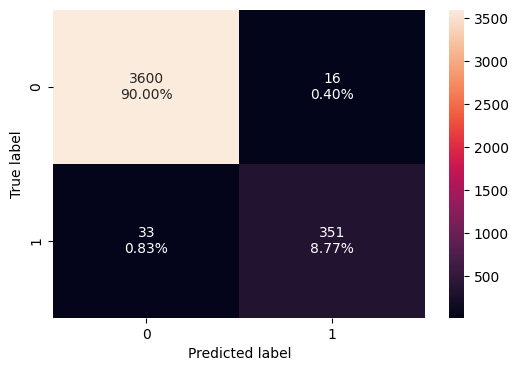

In [0]:
plot_confusion_matrix(dtree2, X_train, y_train)

In [0]:
dtree2_train_perf = model_performance_classification(
    dtree2, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.98775,0.914062,0.956403,0.934754


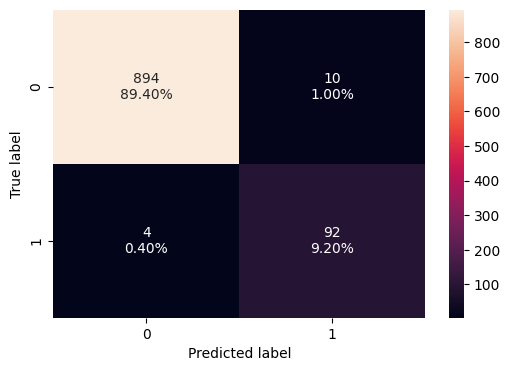

In [0]:
plot_confusion_matrix(dtree2, X_test, y_test)

In [0]:
dtree2_test_perf = model_performance_classification(
    dtree2, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.986,0.958333,0.901961,0.929293


- The training and test scores are very close to each other, indicating a generalized performance.

#### Visualizing the Decision Tree

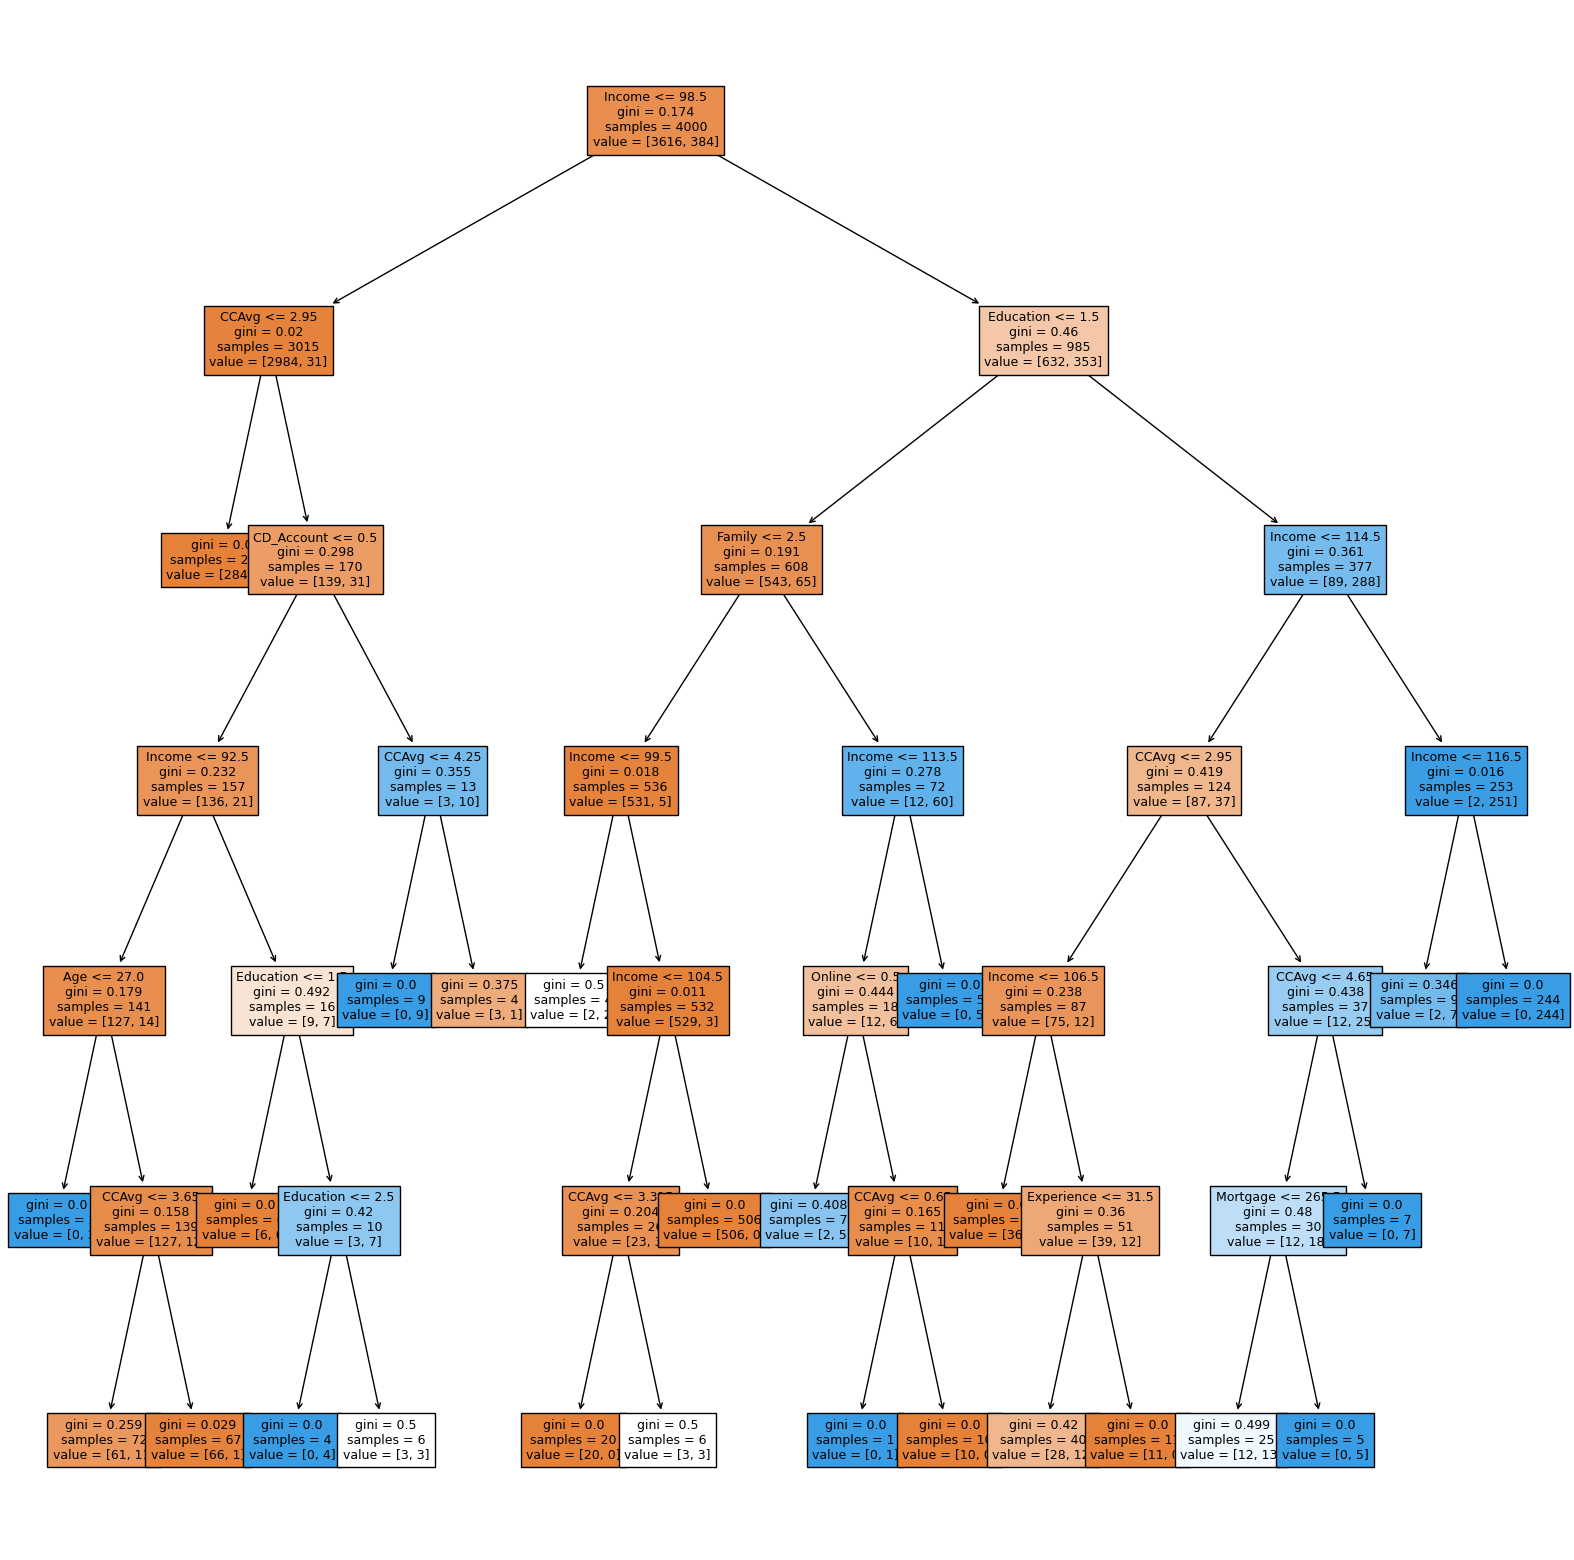

In [0]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

In [0]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree2,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 92.50
|   |   |   |   |--- Age <= 27.00
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |   |--- Age >  27.00
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- weights: [61.00, 11.00] class: 0
|   |   |   |   |   |--- CCAvg >  3.65
|   |   |   |   |   |   |--- weights: [66.00, 1.00] class: 0
|   |   |   |--- Income >  92.50
|   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |   |--- Education >  1.50
|   |   |   |   |   |--- Education <= 2.50
|   |   |   |   |   |   |--- weights: [0.00, 4.00] class: 1
|   |   |   |   |   |--- Education >  2.50
|   |   |   |   |   |   |--- weights: [3.00, 3.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- CCAvg <= 4.25
|   |   |   |   |--- weights: [0.00, 9.00] class: 1
|   |   

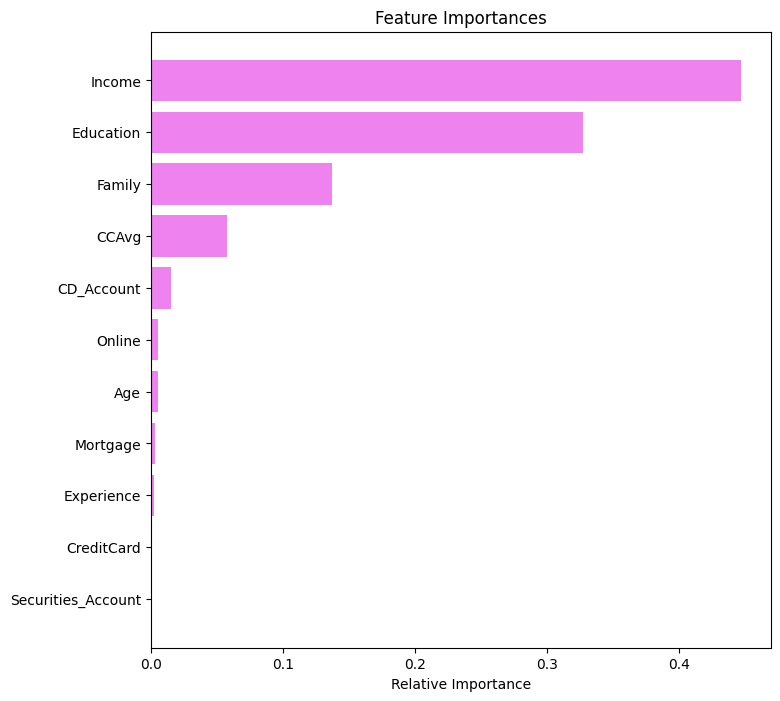

In [0]:
# features used by prepruned tree
importances = dtree2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Prepruned tree uses 9 core features with more emphasis on Income, Education, Family, CCAvg, CD_Account

### Decision Tree (Post-pruning)

In [0]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [0]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000,0.000000
1,0.000244,0.000487
2,0.000246,0.000980
3,0.000296,0.001869
4,0.000306,0.002788
5,0.000331,0.003780
6,0.000333,0.004113
7,0.000333,0.004446
8,0.000333,0.004780
9,0.000350,0.005830


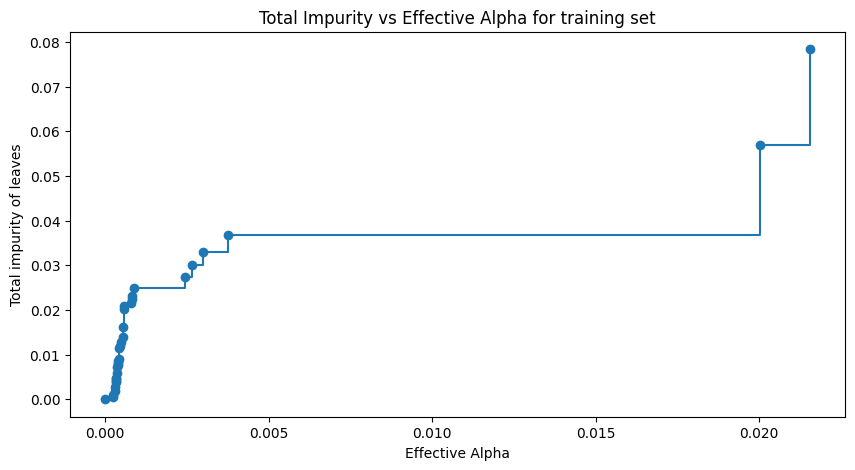

In [0]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

In [0]:
# Initialize an empty list to store the decision tree classifiers
clfs = []

# Iterate over each ccp_alpha value extracted from cost complexity pruning path
for ccp_alpha in ccp_alphas:
    # Create an instance of the DecisionTreeClassifier
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42)

    # Fit the classifier to the training data
    clf.fit(X_train, y_train)

    # Append the trained classifier to the list
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.04760359071815694


- Moving ahead, we remove the last element in
``clfs`` and ``ccp_alphas`` as it corresponds to a trivial tree with only one
node.

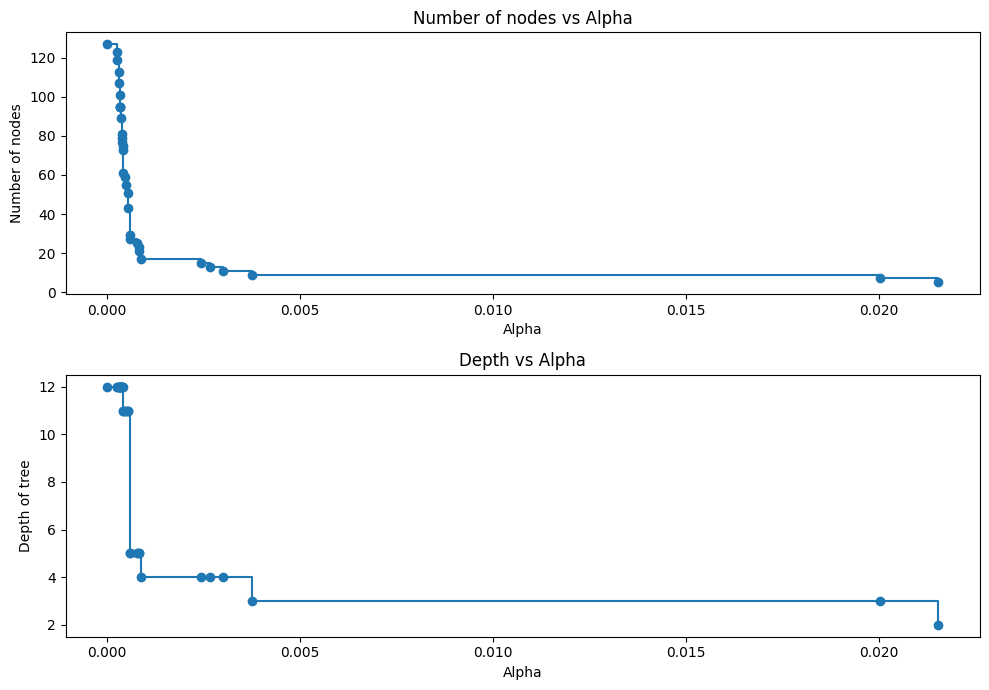

In [0]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

In [0]:
train_f1_scores = []  # Initialize an empty list to store F1 scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    f1_train = f1_score(y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_f1_scores.append(f1_train)

In [0]:
test_f1_scores = []  # Initialize an empty list to store F1 scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    f1_test = f1_score(y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_f1_scores.append(f1_test)


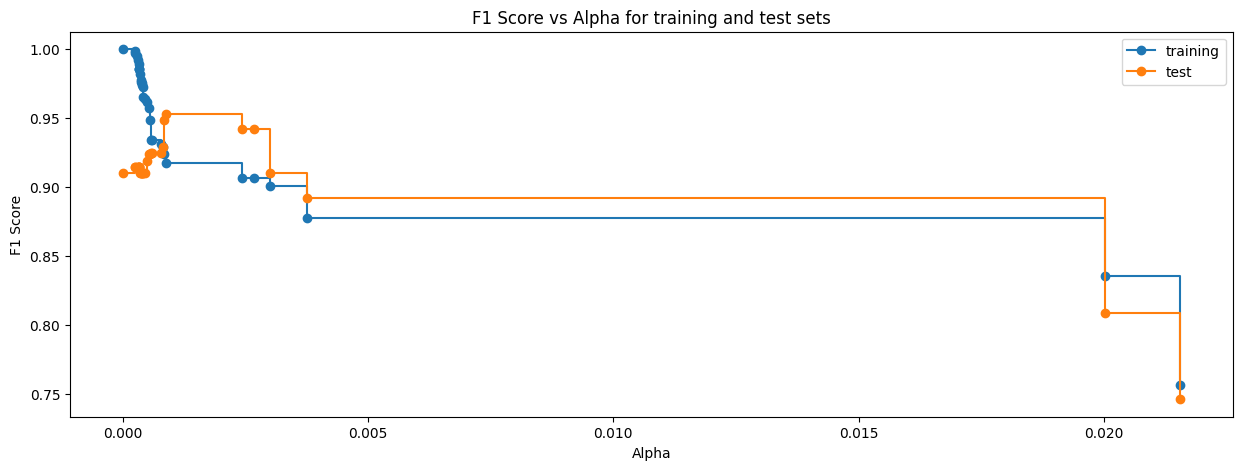

In [0]:
# Create a figure
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")  # Set the label for the x-axis
ax.set_ylabel("F1 Score")  # Set the label for the y-axis
ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_f1_scores, marker="o", label="training", drawstyle="steps-post")

# Plot the testing F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_f1_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

In [0]:
# creating the model where we get highest test F1 Score
index_best_model = np.argmax(test_f1_scores)

# selcting the decision tree model corresponding to the highest test score
dtree3 = clfs[index_best_model]
print(dtree3)

DecisionTreeClassifier(ccp_alpha=0.0008702884311333967, random_state=42)


#### Model Evaluation

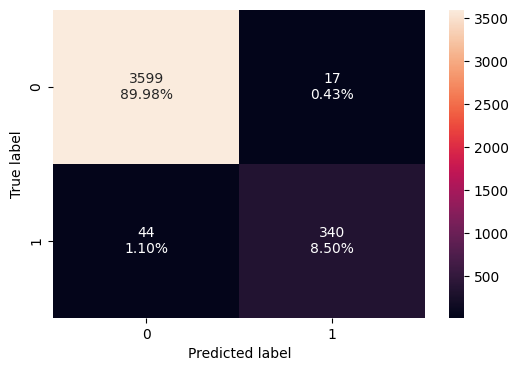

In [0]:
plot_confusion_matrix(dtree3, X_train, y_train)

In [0]:
dtree3_train_perf = model_performance_classification(
    dtree3, X_train, y_train
)
dtree3_train_perf

,Accuracy,Recall,Precision,F1
0,0.98475,0.885417,0.952381,0.917679


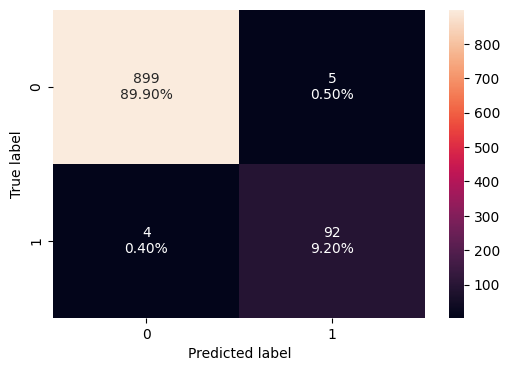

In [0]:
plot_confusion_matrix(dtree3, X_test, y_test)

In [0]:
dtree3_test_perf = model_performance_classification(
    dtree3, X_test, y_test
)
dtree3_test_perf

,Accuracy,Recall,Precision,F1
0,0.991,0.958333,0.948454,0.953368


- The test score is greater than the training score, indicating a generalized performance.

#### Visualizing Decision Tree

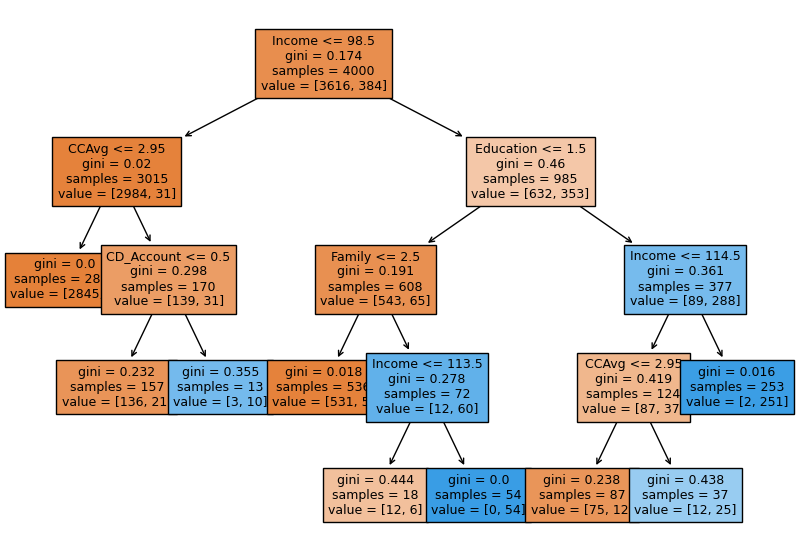

In [0]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(10, 7))

# plotting the decision tree
out = tree.plot_tree(
    dtree3,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

- This is a far less complex tree than the previous one.
- The model used only Income, Education, CCAvg, CD_Account to determine whether the application will be approved or not.

In [0]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree3,    # specify the model
        feature_names=feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2845.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- weights: [136.00, 21.00] class: 0
|   |   |--- CD_Account >  0.50
|   |   |   |--- weights: [3.00, 10.00] class: 1
|--- Income >  98.50
|   |--- Education <= 1.50
|   |   |--- Family <= 2.50
|   |   |   |--- weights: [531.00, 5.00] class: 0
|   |   |--- Family >  2.50
|   |   |   |--- Income <= 113.50
|   |   |   |   |--- weights: [12.00, 6.00] class: 0
|   |   |   |--- Income >  113.50
|   |   |   |   |--- weights: [0.00, 54.00] class: 1
|   |--- Education >  1.50
|   |   |--- Income <= 114.50
|   |   |   |--- CCAvg <= 2.95
|   |   |   |   |--- weights: [75.00, 12.00] class: 0
|   |   |   |--- CCAvg >  2.95
|   |   |   |   |--- weights: [12.00, 25.00] class: 1
|   |   |--- Income >  114.50
|   |   |   |--- weights: [2.00, 251.00] class: 1



# **Model Performance Comparison and Final Model Selection**

In [0]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        dtree1_train_perf.T,
        dtree2_train_perf.T,
        dtree3_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.987750,0.984750
Recall,1.0,0.914062,0.885417
Precision,1.0,0.956403,0.952381
F1,1.0,0.934754,0.917679


In [0]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dtree1_test_perf.T,
        dtree2_test_perf.T,
        dtree3_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.982000,0.986000,0.991000
Recall,0.947917,0.958333,0.958333
Precision,0.875000,0.901961,0.948454
F1,0.910000,0.929293,0.953368


- Both the pre-pruned and post-pruned decision trees exhibit generalized performances

- The pre-pruned decision tree has almost the same or slightly better performance on training and test sets
    - This model uses a more features for decision-making than the post-pruned decision tree
    - This will result in a slightly longer prediction time, we see it performs better than default decision tree

- The post-pruned decision tree has an approx. 4.3% better performance on the test set than the training set
    - This model uses only 5 features for decision-making
    - This will result in a low prediction time but it might not be able to perform well on edge cases in unseen data

- We'll move ahead with the post-pruned decision tree as our final model.

### Feature Importance

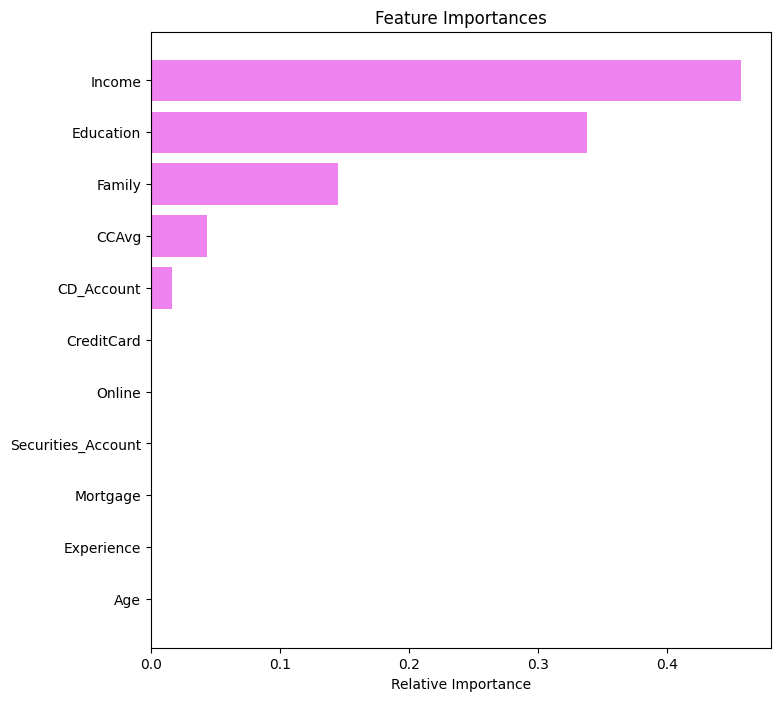

In [0]:
# importance of features in the tree building
importances = dtree3.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

- Income and Education and Family are the most influential attributes in determining credit worthiness.
- CCAvg and CD_Account are the next best attributes to consider.

In [0]:
print("Number of features used in final model:", sum(dtree3.feature_importances_ > 0))

Number of features used in final model: 5


### Predicting on a single data point

In [0]:
%%time
# choosing a data point
applicant_details = X_test.iloc[:1, :]

# making a prediction
approval_prediction = dtree3.predict(applicant_details)

print(approval_prediction)

[0]
CPU times: user 45.9 ms, sys: 5.07 ms, total: 51 ms
Wall time: 408 ms


- The model was able to predict in under half a second.
- Instead of predicting a class (approve/reject), the model can also predict the likelihood of approval.

In [0]:
%%time
# choosing a data point
applicant_details = X_test.iloc[1:2, :]

# making a prediction
approval_prediction = dtree3.predict(applicant_details)

print(approval_prediction)

[1]
CPU times: user 48.1 ms, sys: 4.5 ms, total: 52.6 ms
Wall time: 375 ms


In [0]:
# making a prediction
approval_likelihood = dtree3.predict_proba(applicant_details)

print(approval_likelihood[0, 1])

0.9920948616600791


- This indicates that the model is ~99% confident that the customer has high chances of getting converted to loan applicant

# **Conclusion**

- A post-pruned decision tree was identified as the best-performing model based on accuracy, generalization, and simplicity
- The model achieved a high F1 score of 0.953 on the test set, indicating reliable performance in predicting personal loan acceptance
- It uses only five core features (**Income, Education, Family, CCAvg and CD_Account**), ensuring both interpretability and fast prediction
- Compared to default and pre-pruned trees, this model demonstrates better precision with fewer false positives, while maintaining a low risk of overfitting
- The model is deployment-ready, capable of generating probability scores to support decision-making thresholds

# **Business Recommendations**

- Deploy the post-pruned decision tree model as a first-level screening tool in upcoming personal loan campaigns
- Use the model to automatically approve high-probability customers, improving campaign efficiency and customer experience
- For customers with predicted loan acceptance probabilities below a defined threshold (e.g., 60%), route their profiles for manual review by credit analysts
- Integrating this approach can help reduce turnaround time, lower manual workload, and maximize the return on marketing efforts by targeting the right customers more effectively